In [ ]:
!pip install nlp

     |████████████████████████████████| 1.7 MB 8.4 MB/s 
     |████████████████████████████████| 243 kB 62.7 MB/s 


In [ ]:
%matplotlib inline

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import nlp
import random

from sklearn.metrics import confusion_matrix

def show_history(h):
  epochs_trained= len(h.history['loss'])
  plt.figure(figsize=(16,6))

  plt.subplot(1,2,1)
  plt.plot(range(0, epochs_trained), h.history.get('accuracy'), label='Training')
  plt.plot(range(0,epochs_trained), h.history.get('val_accuracy'), label='Validation')
  plt.ylim([0., 1.])
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()

  plt.subplot(1,2,2)
  plt.plot(range(0, epochs_trained), h.history.get('loss'), label='Training')
  plt.plot(range(0,epochs_trained), h.history.get('val_loss'), label='Validation')
  plt.ylim([0., 1.])
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()


def confusion_matrix(y_true, y_pred, classes):
  cm = confusion_matrix(y_true, y_pred, classes)
  plt.figure(figsize=(8,8))
  sp=plt.subplot(1,1,1)
  ctx= sp.matshow(cm)
  plt.xticks(list(range(0,6)),labels=classes)
  plt.yticks(list(range(0,6)), labels=classes)
  plt.colorbar(ctx)
  plt.show()



In [ ]:
dataset= nlp.load_dataset('emotion')

Downloading:   0%|          | 0.00/3.41k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/6.01k [00:00<?, ?B/s]

Using custom data configuration default


Downloading:   0%|          | 0.00/1.66M [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/204k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/207k [00:00<?, ?B/s]

0 examples [00:00, ? examples/s]

0 examples [00:00, ? examples/s]

0 examples [00:00, ? examples/s]

Dataset emotion downloaded and prepared to /root/.cache/huggingface/datasets/emotion/default/0.0.0/84e07cd366f4451464584cdbd4958f512bcaddb1e921341e07298ce8a9ce42f4. Subsequent calls will reuse this data.


In [ ]:
dataset

{'test': Dataset(features: {'text': Value(dtype='string', id=None), 'label': Value(dtype='string', id=None)}, num_rows: 2000),
 'train': Dataset(features: {'text': Value(dtype='string', id=None), 'label': Value(dtype='string', id=None)}, num_rows: 16000),
 'validation': Dataset(features: {'text': Value(dtype='string', id=None), 'label': Value(dtype='string', id=None)}, num_rows: 2000)}

In [ ]:
train=dataset['train']

val=dataset['validation']

test=dataset['test']

In [ ]:
def get_tweet(data):
  tweet =[x['text'] for x in data]
  label=[x['label'] for x in data]

  return tweet,label

In [ ]:
tweets, labels = get_tweet(train)

In [ ]:
tweets[0], labels[0]

('i didnt feel humiliated', 'sadness')

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer


In [ ]:
tokenizer= Tokenizer(num_words=10000, oov_token='<UNK>')
tokenizer.fit_on_texts(tweets)

In [ ]:
tokenizer.texts_to_sequences([tweets[0]])

[[2, 139, 3, 679]]

### Padding and Truncating sequences



check length of the tweets

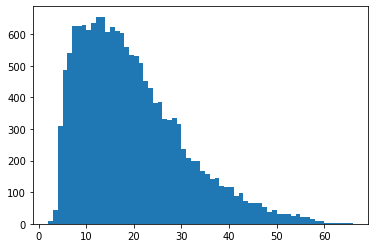

In [ ]:
lengths =[len(text.split(' ')) for text in tweets]

plt.hist(lengths, bins= len(set(lengths)))
plt.show()

padding sequences

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
max_length= 60

In [ ]:
def get_padded_sequence(tokenizer, tweets):
  sequences = tokenizer.texts_to_sequences(tweets)
  padded_sequence = pad_sequences(sequences, maxlen=max_length, truncating='pre',padding='pre')
  return padded_sequence

In [ ]:
train_padded_sequence = get_padded_sequence(tokenizer, tweets)

In [ ]:
train_padded_sequence[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   2, 139,   3, 679], dtype=int32)

### Preparing labels

In [ ]:
classes= set(labels)

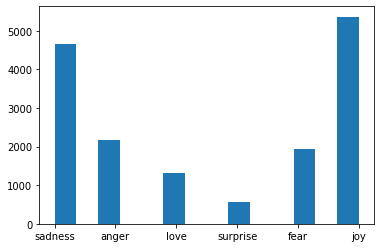

In [ ]:
plt.hist(labels, bins = len(set(labels))+8)
plt.show()

In [ ]:
class_to_index = dict((c,v) for v,c in enumerate(classes))
index_to_class = dict((a,b) for b,a in class_to_index.items())

In [ ]:
class_to_index

{'anger': 1, 'fear': 4, 'joy': 3, 'love': 2, 'sadness': 5, 'surprise': 0}

In [ ]:
index_to_class

{0: 'surprise', 1: 'anger', 2: 'love', 3: 'joy', 4: 'fear', 5: 'sadness'}

In [ ]:
name_to_ids= lambda labels:np.array([class_to_index.get(x) for x in labels])

In [ ]:
train_labels= name_to_ids(labels)

print(train_labels[0])

5


### model building

In [ ]:
model= tf.keras.models.Sequential([
                                   tf.keras.layers.Embedding(10000, 16, input_length=max_length),
                                   tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(20, return_sequences=True)),
                                   tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(20)),
                                   tf.keras.layers.Dense(6, activation='softmax')
])

In [ ]:
model.compile(
    loss= 'sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, 60, 16)            160000    
_________________________________________________________________
bidirectional (Bidirectional (None, 60, 40)            5920      
_________________________________________________________________
bidirectional_1 (Bidirection (None, 40)                9760      
_________________________________________________________________
dense (Dense)                (None, 6)                 246       
Total params: 175,926
Trainable params: 175,926
Non-trainable params: 0
_________________________________________________________________


In [ ]:
val_tweets, val_labels = get_tweet(val)
val_seq=get_padded_sequence(tokenizer, val_tweets)
val_labels=name_to_ids(val_labels)

In [ ]:
val_tweets[0], val_labels[0]

('im feeling quite sad and sorry for myself but ill snap out of it soon', 5)

In [ ]:
h = model.fit(
    train_padded_sequence, train_labels,
    validation_data=(val_seq, val_labels),
    epochs=100,
    callbacks=[
               tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=2)
    ]
)

In [ ]:
show_history(h)

In [ ]:
test_tweets, test_labels = get_tweet(test)
test_seq=get_padded_sequence(tokenizer, test_tweets)
test_labels=name_to_ids(test_labels)

In [ ]:
test_tweets[0], test_labels[0]

('im feeling rather rotten so im not very ambitious right now', 5)

In [ ]:
_ = model.evaluate(test_seq, test_labels)

63/63 [==============================] - 0s 7ms/step - loss: 0.4798 - accuracy: 0.8790


In [ ]:
i= random.randint(0, len(test_labels) -1)

print('Sentence: ' , test_tweets[i])
print('Emotion: ',index_to_class[test_labels[i]])

pred = model.predict(np.expand_dims(test_seq[i], axis=0))[0]

pred_class= index_to_class[np.argmax(pred).astype('uint8')]

print('Prediction : ', pred_class)

Sentence:  i just say that i am not even feeling embarrassed when i pause and rewind my dvred commercials if the breaking dawn preview comes on
Emotion:  sadness
Prediction :  sadness


In [ ]:
preds= model.predict(test_seq)

In [ ]:
preds[0]

array([1.7459122e-06, 4.2887268e-04, 2.9639252e-05, 6.2178202e-05,
       7.1882554e-05, 9.9940574e-01], dtype=float32)

In [ ]:
confusion_matrix(test_labels, np.round(np.argmax(preds)), list(classes))